In [ ]:
! mkdir cuda

In [ ]:
# Mount Google Drive
from google.colab import drive
#drive.flush_and_unmount()
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
! ls -la gdrive/MyDrive/Colab\ Notebooks

total 812
-rw------- 1 root root   4021 Sep 28 11:30 MainPracticaIntroFAA.ipynb
-rw------- 1 root root 826831 Oct  7 16:25 Tutorial_SIMD_intirnsics.ipynb
-rw------- 1 root root    306 Sep 28 10:45 Untitled


In [ ]:
# Copy source code to your folder
!cp -r /content/gdrive/MyDrive/CAP/P2/EJ3/images/* cuda/

# Create soft links
!ln -s /content/gdrive/MyDrive/CAP/P2/EJ3/images cuda

!cp  /content/gdrive/MyDrive/CAP/P2/EJ3/stb_image.h cuda/
!cp /content/gdrive/MyDrive/CAP/P2/EJ3/stb_image_write.h cuda

# Create soft links
!ln -s /content/gdrive/MyDrive/CAP/P2/EJ3/stdb_image.h cuda/
!ln -s /content/gdrive/MyDrive/CAP/P2/EJ3/stdb_image_write.h cuda

# List folder
!ls -la cuda/

total 7036
drwxr-xr-x 2 root root    4096 Oct 25 19:19 .
drwxr-xr-x 1 root root    4096 Oct 25 19:19 ..
-rw------- 1 root root  702701 Oct 25 19:19 4k.jpg
-rw------- 1 root root 5633174 Oct 25 19:19 8k.jpg
-rw------- 1 root root  274739 Oct 25 19:19 FHD.jpg
-rw------- 1 root root  159822 Oct 25 19:19 HD.jpg
lrwxrwxrwx 1 root root      41 Oct 25 19:19 images -> /content/gdrive/MyDrive/CAP/P2/EJ3/images
-rw------- 1 root root   55682 Oct 25 19:19 SD.jpg
-rw------- 1 root root  279339 Oct 25 19:19 stb_image.h
-rw------- 1 root root   71221 Oct 25 19:19 stb_image_write.h
lrwxrwxrwx 1 root root      47 Oct 25 19:19 stdb_image.h -> /content/gdrive/MyDrive/CAP/P2/EJ3/stdb_image.h
lrwxrwxrwx 1 root root      53 Oct 25 19:19 stdb_image_write.h -> /content/gdrive/MyDrive/CAP/P2/EJ3/stdb_image_write.h


In [ ]:
%%writefile cuda/greyScale.cu
#include <cuda.h>
#include <cuda_runtime.h>
#include <stdio.h>
#include <stdint.h>
#include <math.h>
#include <sys/time.h>
#define STB_IMAGE_IMPLEMENTATION
#include "stb_image.h"
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "stb_image_write.h"

__global__ void greyScale(uint8_t *d_grey_image, uint8_t *d_rgb_image, int width, int height) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    int j = blockIdx.y * blockDim.y + threadIdx.y;

    if (i < width && j < height) {
        int idx = (j * width + i) * 4;
        int r = d_rgb_image[idx];
        int g = d_rgb_image[idx + 1];
        int b = d_rgb_image[idx + 2];
        d_grey_image[j * width + i] = (uint8_t)(0.2989 * r + 0.5870 * g + 0.1140 * b);
    }
}

int main(int argc, char **argv) {
  int width, height, nchannels;
  struct timeval fin, ini;
  uint8_t *d_rgb_image, *d_grey_image;

  if (argc < 2)
  {
        printf("Usage: %s <image1> [<image2> ...]\n", argv[0]);

  }
  // For each image
    // Bucle 0
    for (int file_i = 1; file_i < argc; file_i++)
    {
        printf("[info] Processing %s\n", argv[file_i]);
        /****** Reading file ******/
        uint8_t *rgb_image = stbi_load(argv[file_i], &width, &height, &nchannels, 4);
        if (!rgb_image)
        {
            perror("Image could not be opened");
        }

        /****** Allocating memory ******/
        // - RGB2Grey
        uint8_t *grey_image = (uint8_t*)malloc(width * height);
        if (!grey_image)
        {
            perror("Could not allocate memory");
        }

        cudaMalloc((void **)&d_grey_image, width * height * sizeof(uint8_t));
        cudaMalloc((void **)&d_rgb_image, width * height * 4 * sizeof(uint8_t));

        cudaMemcpy(d_rgb_image, rgb_image, width * height * 4 * sizeof(uint8_t), cudaMemcpyHostToDevice);

        // - Filenames
        for (int i = strlen(argv[file_i]) - 1; i >= 0; i--)
        {
            if (argv[file_i][i] == '.')
            {
                argv[file_i][i] = 0;
                break;
            }
        }

        char *grey_image_filename = 0;
        asprintf(&grey_image_filename, "%s_grey.jpg", argv[file_i]);
        if (!grey_image_filename)
        {
            perror("Could not allocate memory");
            exit(-1);
        }

        /****** Computations ******/
        //Esto no es necesario por que el numero de canales siempre va a ser 4
        printf("[info] %s: width=%d, height=%d, nchannels=%d\n", argv[file_i], width, height, nchannels);

        if (nchannels != 3 && nchannels != 4)
        {
            printf("[error] Num of channels=%d not supported. Only three (RGB), four (RGBA) are supported.\n", nchannels);
            continue;
        }

        dim3 blockSize(16, 16);
        dim3 gridSize((width + blockSize.x - 1) / blockSize.x, (height + blockSize.y - 1) / blockSize.y);

        gettimeofday(&ini, NULL);
        // RGB to grey scale
        greyScale<<<gridSize, blockSize>>>(d_grey_image, d_rgb_image, width, height);
        cudaDeviceSynchronize();
        cudaMemcpy(grey_image, d_grey_image, width * height * sizeof(uint8_t), cudaMemcpyDeviceToHost);
        gettimeofday(&fin, NULL);
        stbi_write_jpg(grey_image_filename, width, height, 1, grey_image, 10);

        free(rgb_image);

        FILE *pf = fopen("time.txt", "a");
        fprintf(pf, "%s %f\n", argv[file_i], ((fin.tv_sec * 1000000 + fin.tv_usec) - (ini.tv_sec * 1000000 + ini.tv_usec)) * 1.0 / 1000000.0);

        cudaFree(d_grey_image);
        cudaFree(d_rgb_image);
        free(grey_image_filename);
        free(grey_image);
        fclose(pf);
    }

    return 0;
}

Overwriting cuda/greyScale.cu


In [ ]:
%%writefile cuda/greyScale_intrin.c

#include <math.h>
#include <stdint.h>
#include <stdio.h>
#include <sys/time.h>
#define STB_IMAGE_IMPLEMENTATION
#include "stb_image.h"
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "stb_image_write.h"
#include <immintrin.h>

static inline void getRGB(uint8_t *im, int width, int height, int nchannels,
                          int x, int y, int *r, int *g, int *b) {

  unsigned char *offset = im + (x + width * y) * nchannels;
  *r = offset[0];
  *g = offset[1];
  *b = offset[2];
}

int main(int nargs, char **argv) {
  int width, height, nchannels;
  struct timeval fin, ini;

  if (nargs < 2) {
    printf("Usage: %s <image1> [<image2> ...]\n", argv[0]);
  }

  // For each image
  // Bucle 0
  for (int file_i = 1; file_i < nargs; file_i++) {
    printf("[info] Processing %s\n", argv[file_i]);
    /****** Reading file ******/
    uint8_t *rgb_image =
        stbi_load(argv[file_i], &width, &height, &nchannels, 4);
    if (!rgb_image) {
      perror("Image could not be opened");
    }

    /****** Allocating memory ******/
    // - RGB2Grey
    uint8_t *grey_image = malloc(width * height);
    if (!grey_image) {
      perror("Could not allocate memory");
    }

    // - Filenames
    for (int i = strlen(argv[file_i]) - 1; i >= 0; i--) {
      if (argv[file_i][i] == '.') {
        argv[file_i][i] = 0;
        break;
      }
    }

    char *grey_image_filename = 0;
    asprintf(&grey_image_filename, "%s_grey_intrin.jpg", argv[file_i]);
    if (!grey_image_filename) {
      perror("Could not allocate memory");
      exit(-1);
    }

    /****** Computations ******/
    printf("[info] %s: width=%d, height=%d, nchannels=%d\n", argv[file_i],
           width, height, nchannels);

    if (nchannels != 3 && nchannels != 4) {
      printf("[error] Num of channels=%d not supported. Only three (RGB), four "
             "(RGBA) are supported.\n",
             nchannels);
      continue;
    }

    gettimeofday(&ini, NULL);
    // RGB to grey scale

    for (int j = 0; j < height; j++) {
      for (int i = 0; i < width; i += 4) {
        __m256i orden = _mm256_setr_epi32(0, 4, 1, 5, 0, 2, 0, 1);
        __m256 coeficiente =
            _mm256_setr_ps(0.2989, 0.5870, 0.1140, 0.0, 0.2989, 0.5870, 0.1140,
                           0.0); // coeficientes r, g y b
        // getRGB(rgb_image, width, height, 4, i, j, &r, &g, &b);
        // cargamos en los vectores el pixel
        __m128i vec1 =
            _mm_loadl_epi64((__m128i *)(rgb_image + (i + width * j) * 4));
        __m128i vec2 =
            _mm_loadl_epi64((__m128i *)(rgb_image + (i + width * j) * 4 + 8));

        // Hay que convertir los vectores en float para poder operar con ellos
        // primero lo convertimos entero y luego a float

        __m256i vec1i = _mm256_cvtepu8_epi32(vec1);
        __m256i vec2i = _mm256_cvtepu8_epi32(vec2);

        __m256 vec1f = _mm256_cvtepi32_ps(vec1i);
        __m256 vec2f = _mm256_cvtepi32_ps(vec2i);

        // Multiplicamos los coeficientes de cada color por los vectores
        __m256 res1 = _mm256_mul_ps(vec1f, coeficiente);
        __m256 res2 = _mm256_mul_ps(vec2f, coeficiente);

        // Sumamos horizontalmente para obtener el vector final
        __m256 res = _mm256_hadd_ps(res1, res2);
        __m256 total = _mm256_hadd_ps(res, res);

        // ordenamos los valores
        total = _mm256_permutevar8x32_ps(total, orden);
        // Convertimos a entero de 32 bits
        __m128i gris = _mm_cvtps_epi32(_mm256_extractf128_ps(total, 0));

        // Guardamos los valores

        uint32_t *ptr = (uint32_t *)&gris;

        grey_image[(j * width) + i] = ptr[0];
        grey_image[(j * width) + i + 1] = ptr[1];
        grey_image[(j * width) + i + 2] = ptr[2];
        grey_image[(j * width) + i + 3] = ptr[3];
      }
    }

    stbi_write_jpg(grey_image_filename, width, height, 1, grey_image, 10);
    free(rgb_image);

    gettimeofday(&fin, NULL);

    FILE *pf = fopen("time_intrin.txt", "a");
    fprintf(pf, "%s Tiempo: %f\n", argv[file_i],
            ((fin.tv_sec * 1000000 + fin.tv_usec) -
             (ini.tv_sec * 1000000 + ini.tv_usec)) *
                1.0 / 1000000.0);
    free(grey_image_filename);
  }
}

Overwriting cuda/greyScale_intrin.c


In [ ]:
!nvcc cuda/greyScale.cu -o cuda/greyScale
!gcc -O3 -march=native -fwhole-program -Wall -D_GNU_SOURCE -std=gnu99 -o cuda/greyScale_intrin cuda/greyScale_intrin.c -lm
!rm time.txt time_intrin.txt
avg = 5
for i in range(avg):
  !./cuda/greyScale cuda/images/SD.jpg cuda/images/HD.jpg cuda/images/FHD.jpg cuda/images/4k.jpg cuda/images/8k.jpg
  !./cuda/greyScale_intrin cuda/images/8k.jpg cuda/images/4k.jpg cuda/images/FHD.jpg cuda/images/HD.jpg cuda/images/SD.jpg


cuda/stb_image.h(4207): warning #550-D: variable "old_limit" was set but never used
     unsigned int cur, limit, old_limit;
                              ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

cuda/stb_image.h(5121): warning #550-D: variable "idata_limit_old" was set but never used
                 stbi__uint32 idata_limit_old = idata_limit;
                              ^

cuda/stb_image.h(6894): warning #550-D: variable "out_size" was set but never used
        int out_size = 0;
            ^

cuda/stb_image.h(6895): warning #550-D: variable "delays_size" was set but never used
        int delays_size = 0;
            ^

cuda/greyScale_intrin.c: In function ‘main’:
cuda/greyScale_intrin.c:56:5: warning: ignoring return value of ‘asprintf’ declared with attribute ‘warn_unused_result’ []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-result-Wunused-result]8;;]
   56 |     asprintf(&grey_image_filename, "%s_grey_in

In [ ]:
!cat time.txt

cuda/images/SD 0.000452
cuda/images/HD 0.000426
cuda/images/FHD 0.000950
cuda/images/4k 0.003302
cuda/images/8k 0.029192
cuda/images/SD 0.000528
cuda/images/HD 0.000443
cuda/images/FHD 0.000929
cuda/images/4k 0.003187
cuda/images/8k 0.029233
cuda/images/SD 0.000515
cuda/images/HD 0.000456
cuda/images/FHD 0.000937
cuda/images/4k 0.003365
cuda/images/8k 0.029376
cuda/images/SD 0.000459
cuda/images/HD 0.000452
cuda/images/FHD 0.000951
cuda/images/4k 0.003164
cuda/images/8k 0.030821
cuda/images/SD 0.000624
cuda/images/HD 0.000521
cuda/images/FHD 0.000915
cuda/images/4k 0.003208
cuda/images/8k 0.035659


In [ ]:
!cat time_intrin.txt

cuda/images/SD Tiempo: 0.019205
cuda/images/HD Tiempo: 0.015360
cuda/images/FHD Tiempo: 0.057934
cuda/images/4k Tiempo: 0.177234
cuda/images/8k Tiempo: 0.408426
cuda/images/SD Tiempo: 0.009903
cuda/images/HD Tiempo: 0.022352
cuda/images/FHD Tiempo: 0.063759
cuda/images/4k Tiempo: 0.167223
cuda/images/8k Tiempo: 0.613911
cuda/images/SD Tiempo: 0.008201
cuda/images/HD Tiempo: 0.016402
cuda/images/FHD Tiempo: 0.030103
cuda/images/4k Tiempo: 0.099899
cuda/images/8k Tiempo: 0.397224
cuda/images/SD Tiempo: 0.007797
cuda/images/HD Tiempo: 0.016219
cuda/images/FHD Tiempo: 0.029112
cuda/images/4k Tiempo: 0.096846
cuda/images/8k Tiempo: 0.411111
cuda/images/SD Tiempo: 0.007583
cuda/images/HD Tiempo: 0.015846
cuda/images/FHD Tiempo: 0.029557
cuda/images/4k Tiempo: 0.098512
cuda/images/8k Tiempo: 0.382034


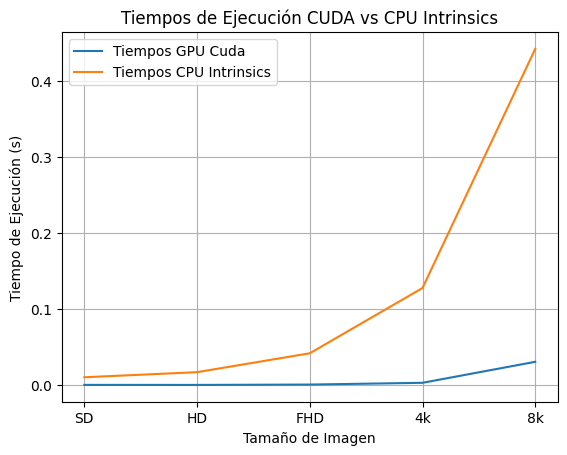

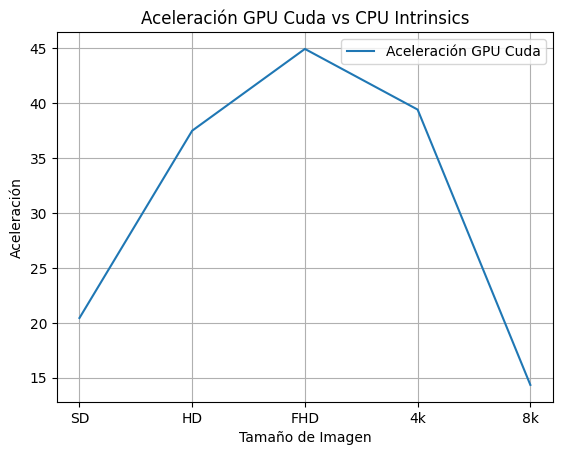

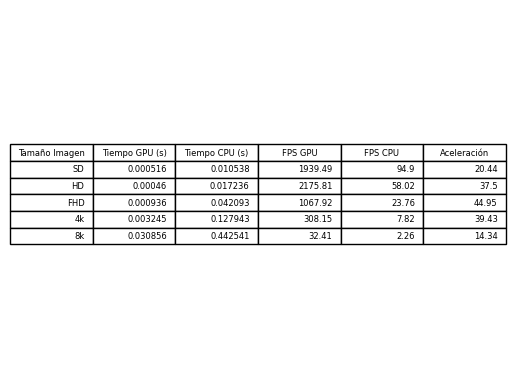

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df_cuda = pd.read_csv("time.txt", header=None, sep=' ', names=['imagen', 'tiempo'])
df_intrin = pd.read_csv("time_intrin.txt", header=None, sep=' ', names=['imagen', 'tiempo'])

df_cuda = df_cuda['tiempo']
df_intrin = df_intrin['tiempo']

sizes = ["SD", "HD", "FHD", "4k", "8k"]
time_avg_cuda = []
time_avg_intrin = []

for i in range(avg):
  time_avg_cuda.append(np.mean(df_cuda[i::avg]))
  time_avg_intrin.append(np.mean(df_intrin[i::avg]))

plt.plot(sizes, time_avg_cuda, label="Tiempos GPU Cuda")
plt.plot(sizes, time_avg_intrin, label="Tiempos CPU Intrinsics")
plt.title("Tiempos de Ejecución CUDA vs CPU Intrinsics")
plt.ylabel("Tiempo de Ejecución (s)")
plt.xlabel("Tamaño de Imagen")
plt.grid()
plt.legend()
plt.show()

accel = np.array(time_avg_intrin) / np.array(time_avg_cuda)

plt.plot(sizes, accel, label="Aceleración GPU Cuda")
plt.title("Aceleración GPU Cuda vs CPU Intrinsics")
plt.ylabel("Aceleración")
plt.xlabel("Tamaño de Imagen")
plt.grid()
plt.legend()
plt.show()

fps_cuda = [1 / t for t in time_avg_cuda]
fps_intrin = [1 / t for t in time_avg_intrin]

fig, ax = plt.subplots()
ax.axis('off')

columns = ["Tamaño Imagen", "Tiempo GPU (s)", "Tiempo CPU (s)", "FPS GPU", "FPS CPU", "Aceleración"]
datos = []
for i in range(len(sizes)):
    row = [sizes[i], round(time_avg_cuda[i], 6), round(time_avg_intrin[i], 6), round(fps_cuda[i], 2), round(fps_intrin[i], 2), round(accel[i], 2)]
    datos.append(row)

ax.table(cellText=datos, colLabels=columns, loc='center')

plt.show()